<a href="https://colab.research.google.com/github/redrosesarecool/staz/blob/main/regresja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Regresja Gaussa

In [ ]:
import pandas as pd

file_path = "/content/drive/My Drive/r_v_montecarlo.dat"
df_all = pd.read_csv(file_path, delim_whitespace=True)
print(df_all.head())

         R          V
0  2.16208  205.52478
1  2.30257  200.57954
2  2.44236  196.41595
3  2.58141  197.63277
4  2.71967  197.12877


/tmp/ipython-input-904907318.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_all = pd.read_csv(file_path, delim_whitespace=True)


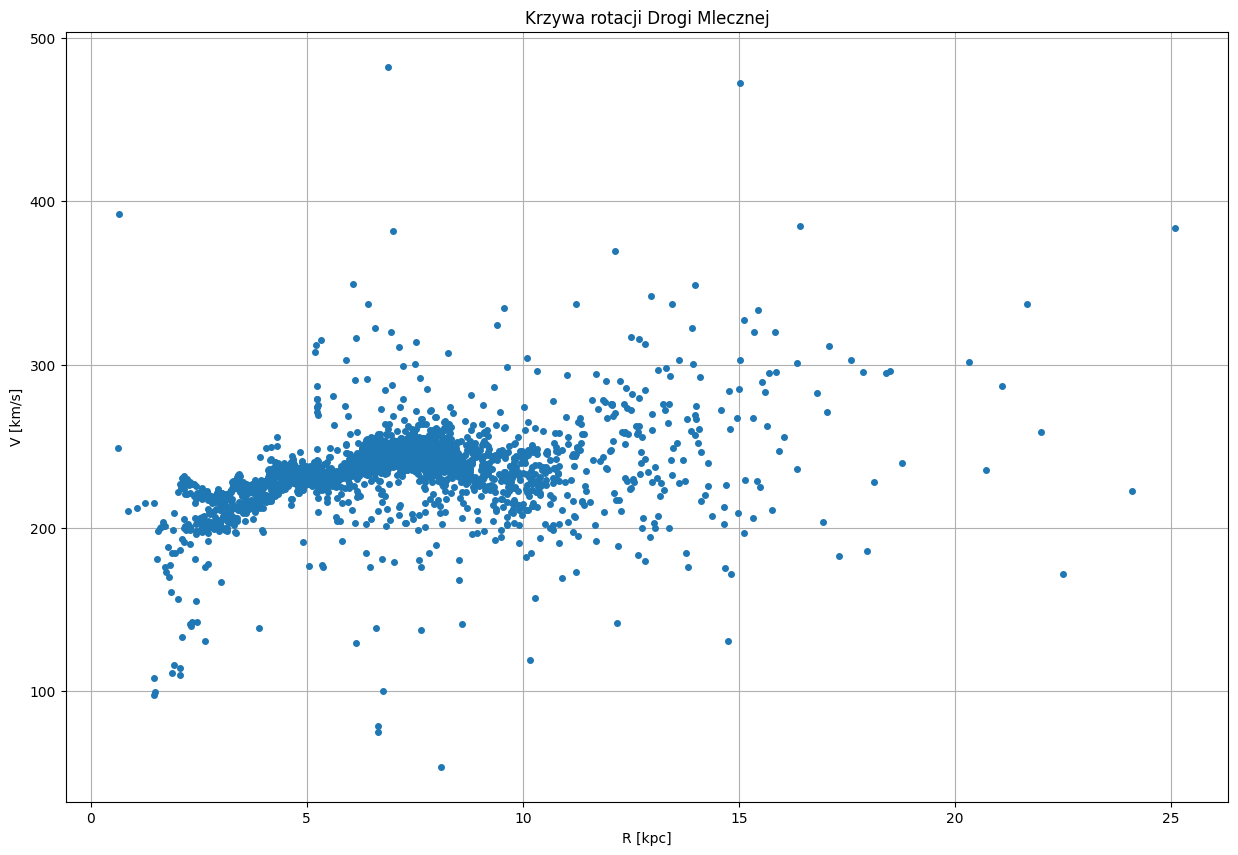

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# wykres R vs V
plt.figure(figsize=(15,10))
plt.plot(df_all["R"], df_all["V"], 'o', markersize=4)
plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("Krzywa rotacji Drogi Mlecznej")
plt.grid(True)
plt.show()

Dopasowane parametry: a=254.82, b=15.20, c=22.46


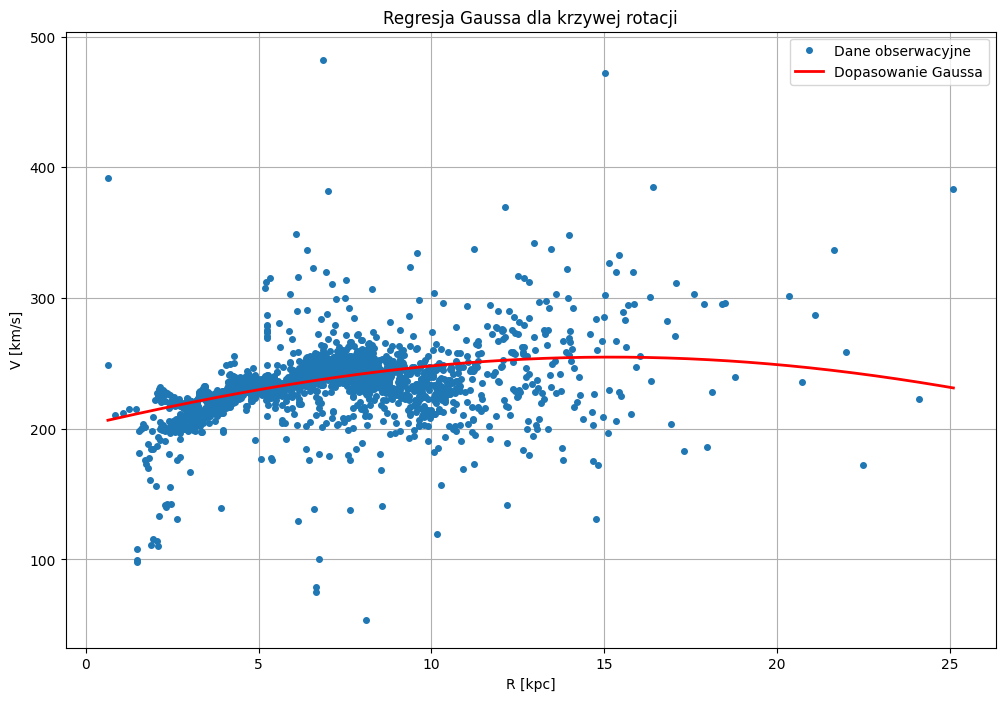

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# definicja funkcji gaussa z wzoru
def gauss(R, a, b, c):
    return a * np.exp(-((R - b)**2) / (2 * c**2))

# dopasowanie modelu do danych
R = df_all["R"].values
V = df_all["V"].values

p0 = [230, 8, 2]  # początkowe parametry: amplituda, środek, szerokość

params, cov = curve_fit(gauss, R, V, p0=p0) # dopasowanie - opis poniżej

a, b, c = params # parametry dopasowania
print(f"Dopasowane parametry: a={a:.2f}, b={b:.2f}, c={c:.2f}")

# dopasowanie R i V do wykresu
R_fit = np.linspace(R.min(), R.max(), 500)
V_fit = gauss(R_fit, *params)

# wykres
plt.figure(figsize=(12,8))
plt.plot(R, V, 'o', markersize=4, label='Dane obserwacyjne')
plt.plot(R_fit, V_fit, 'r-', linewidth=2, label='Dopasowanie Gaussa')
plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("Regresja Gaussa dla krzywej rotacji")
plt.legend()
plt.grid(True)
plt.show()

curve_fit z scipy.optimize służy do dopasowania dowolnej funkcji matematycznej do danych metodą nieliniowych najmniejszych kwadratów

* funkcja - to funkcja, którą chcesz dopasować, np. gauss(R, a, b, c). Musi przyjmować pierwszy argument jako x (tu R), a kolejne jako parametry dopasowywane (a, b, c).
* xdata, ydata - dane eksperymentalne: xdata - wartości niezależne (promień galaktocentryczny R [kpc]), ydata - wartości zależne (prędkość rotacji V [km/s])
* p0 - initial guess - początkowe przybliżenie parametrów

# Gaussian Process Regression

**ConstantKernel(1.0, (1e-3, 1e3))** to amplituda (czyli ogólna skala wartości funkcji). Wartość 1.0 oznacza, że model zaczyna z amplitudą 1. Zakres (1e-3, 1e3) mówi, że optymalizator może zmieniać tę amplitudę między 0.001 a 1000. Kontroluje to „wysokość” przewidywanej funkcji oraz określa „ile” zmienności ma model, czy dane są niemal płaskie, czy mają duże amplitudy zmian

**RBF(length_scale=0.3, length_scale_bounds=(0.1, 10.0))** to tzw. Radial Basis Function kernel, znany też jako Gaussian kernel. To on decyduje, jak gładka jest funkcja dopasowania.
length_scale to długość skali (czyli odległość, na której punkty są jeszcze ze sobą skorelowane). Mała wartość sprawia, że krzywa dopasowuje się bardzo lokalnie (falowanie, dopasowanie do szumu). Duża wartość sprawie, że krzywa jest gładka i reaguje tylko na duże zmiany trendu.
length_scale_bounds to zakres wartości, w jakim optymalizator może szukać najlepszej długości skali.

**WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 10))** to składnik szumowy, który modeluje niepewność lub rozrzut danych. Dzięki temu GPR nie stara się idealnie dopasować każdego punktu, tylko uwzględnia, że dane są „hałaśliwe”.
noise_level to początkowy poziom szumu (wariancja błędu).
noise_level_bounds to zakres dopuszczalnych wartości podczas dopasowania.

# Gaussian Process Regression - R, V

length_scale=2.0

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# dane
file_path = "/content/drive/My Drive/all_montecarlo_output-kopia.dat"

# tylko kolumny R i V
df = pd.read_csv(
    file_path,
    sep=r"\s+",
    comment="#",
    on_bad_lines="skip",   # pomija wiersze z błędami formatowania
    usecols=["R", "V"]     # tylko potrzebne kolumny
)

# usunięcie pojawiających się NaN-y
df = df.dropna(subset=["R", "V"])

# przygotowanie danych
R = df["R"].values.reshape(-1, 1)
V = df["V"].values

# definicja jądra (kernel)
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=2.0, length_scale_bounds=(0.1, 20.0)) \
          + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 10))

# dopasowanie modelu GPR
gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.0, n_restarts_optimizer=5, normalize_y=True)
gpr.fit(R, V)

print("\nDopasowane jądro (kernel):")
print(gpr.kernel_)

# predykcja na gęstej siatce R
R_pred = np.linspace(df["R"].min(), df["R"].max(), 400).reshape(-1, 1)
V_pred, V_std = gpr.predict(R_pred, return_std=True)



Dopasowane jądro (kernel):
1.29**2 * RBF(length_scale=0.198) + WhiteKernel(noise_level=0.65)


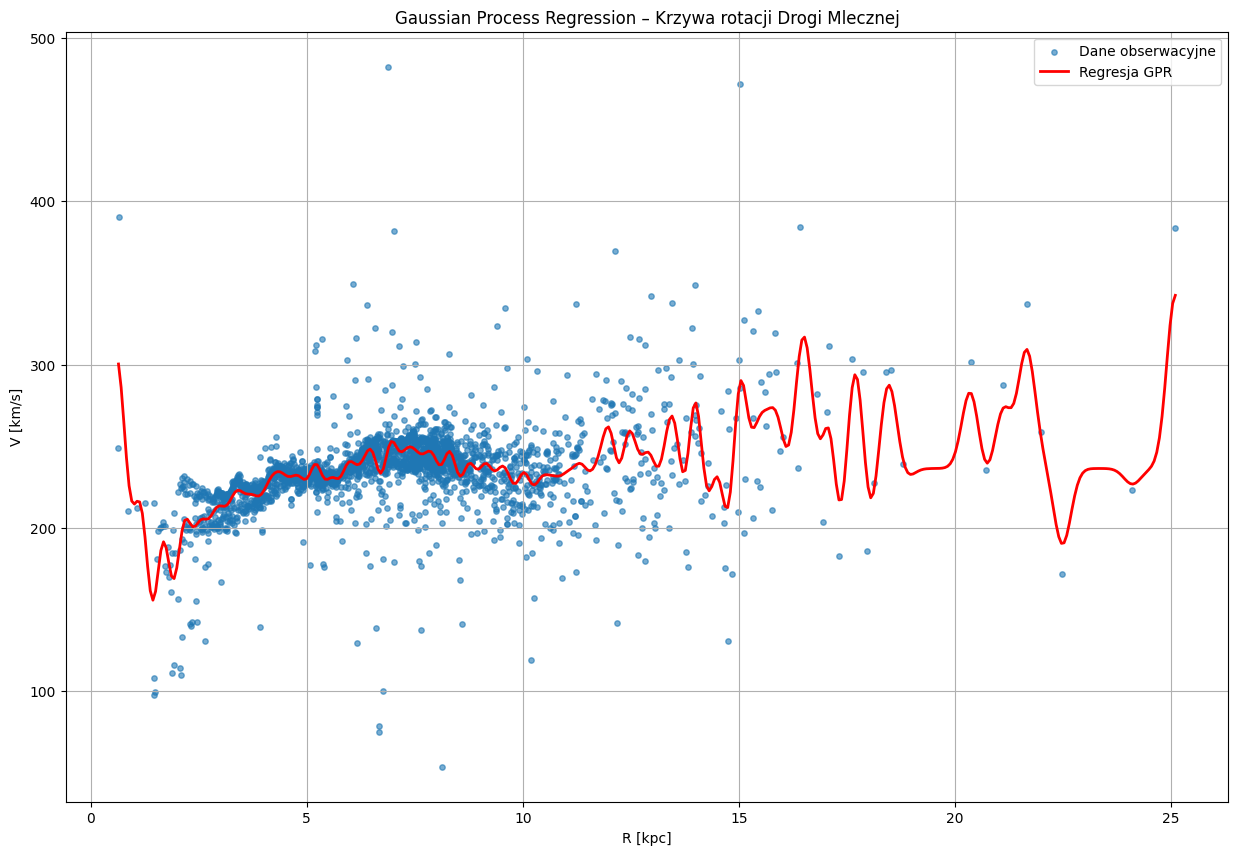

In [24]:
# wykres
plt.figure(figsize=(15, 10))
plt.scatter(R, V, color='tab:blue', s=15, label='Dane obserwacyjne', alpha=0.6)
plt.plot(R_pred, V_pred, 'r-', lw=2, label='Regresja GPR')


plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("Gaussian Process Regression – Krzywa rotacji Drogi Mlecznej")
plt.legend()
plt.grid(True)
plt.show()

length_scale=0.3


Dopasowane jądro (kernel):
1.29**2 * RBF(length_scale=0.198) + WhiteKernel(noise_level=0.65)


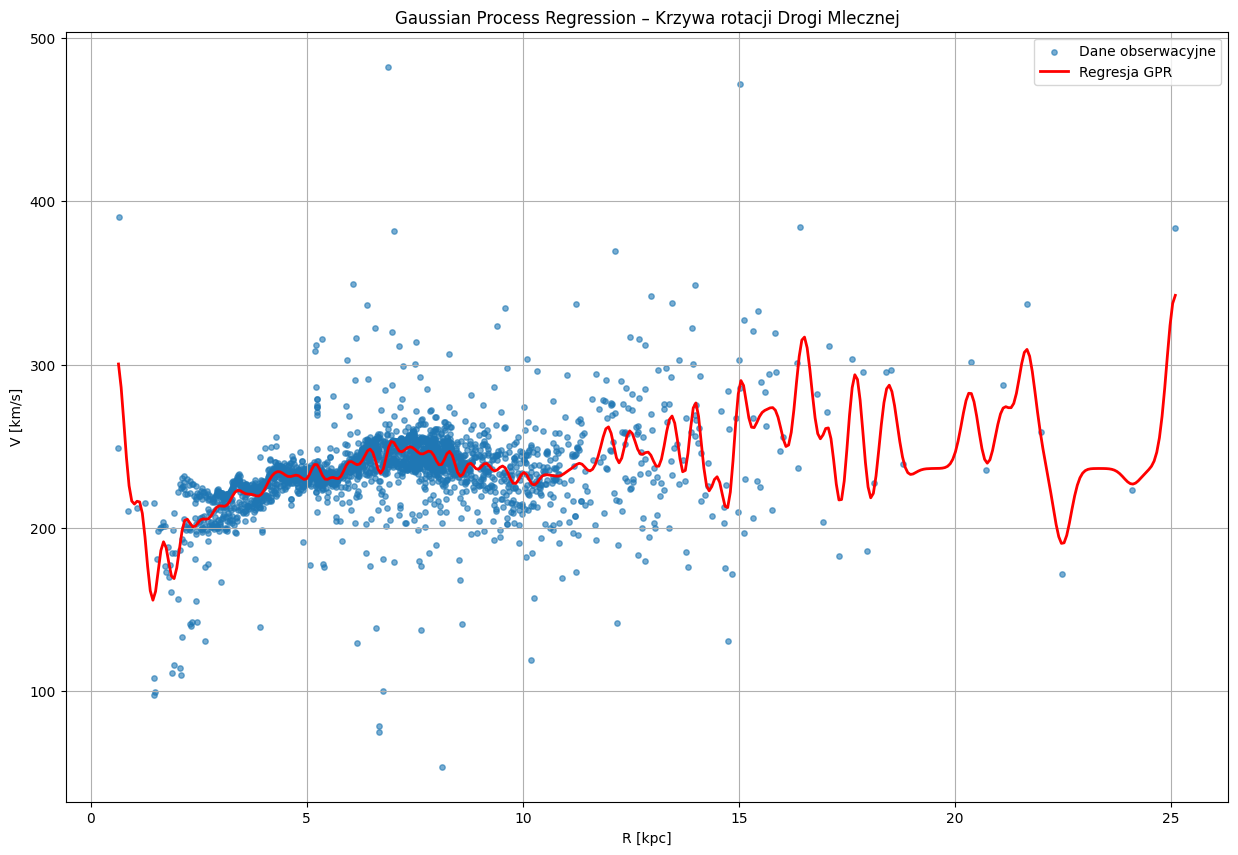

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# dane
file_path = "/content/drive/My Drive/all_montecarlo_output-kopia.dat"

# tylko kolumny R i V
df = pd.read_csv(
    file_path,
    sep=r"\s+",
    comment="#",
    on_bad_lines="skip",   # pomija wiersze z błędami formatowania
    usecols=["R", "V"]     # tylko potrzebne kolumny
)

# usunięcie pojawiających się NaN-y
df = df.dropna(subset=["R", "V"])

# przygotowanie danych
R = df["R"].values.reshape(-1, 1)
V = df["V"].values

# definicja jądra (kernel)
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=0.3, length_scale_bounds=(0.1, 10.0)) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 10))
# dopasowanie modelu GPR
gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.0, n_restarts_optimizer=5, normalize_y=True)
gpr.fit(R, V)

print("\nDopasowane jądro (kernel):")
print(gpr.kernel_)

# predykcja na gęstej siatce R
R_pred = np.linspace(df["R"].min(), df["R"].max(), 400).reshape(-1, 1)
V_pred, V_std = gpr.predict(R_pred, return_std=True)

# wykres
plt.figure(figsize=(15, 10))
plt.scatter(R, V, color='tab:blue', s=15, label='Dane obserwacyjne', alpha=0.6)
plt.plot(R_pred, V_pred, 'r-', lw=2, label='Regresja GPR')


plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("Gaussian Process Regression – Krzywa rotacji Drogi Mlecznej")
plt.legend()
plt.grid(True)
plt.show()


length_scale=15


Dopasowane jądro (kernel):
1.29**2 * RBF(length_scale=0.198) + WhiteKernel(noise_level=0.65)


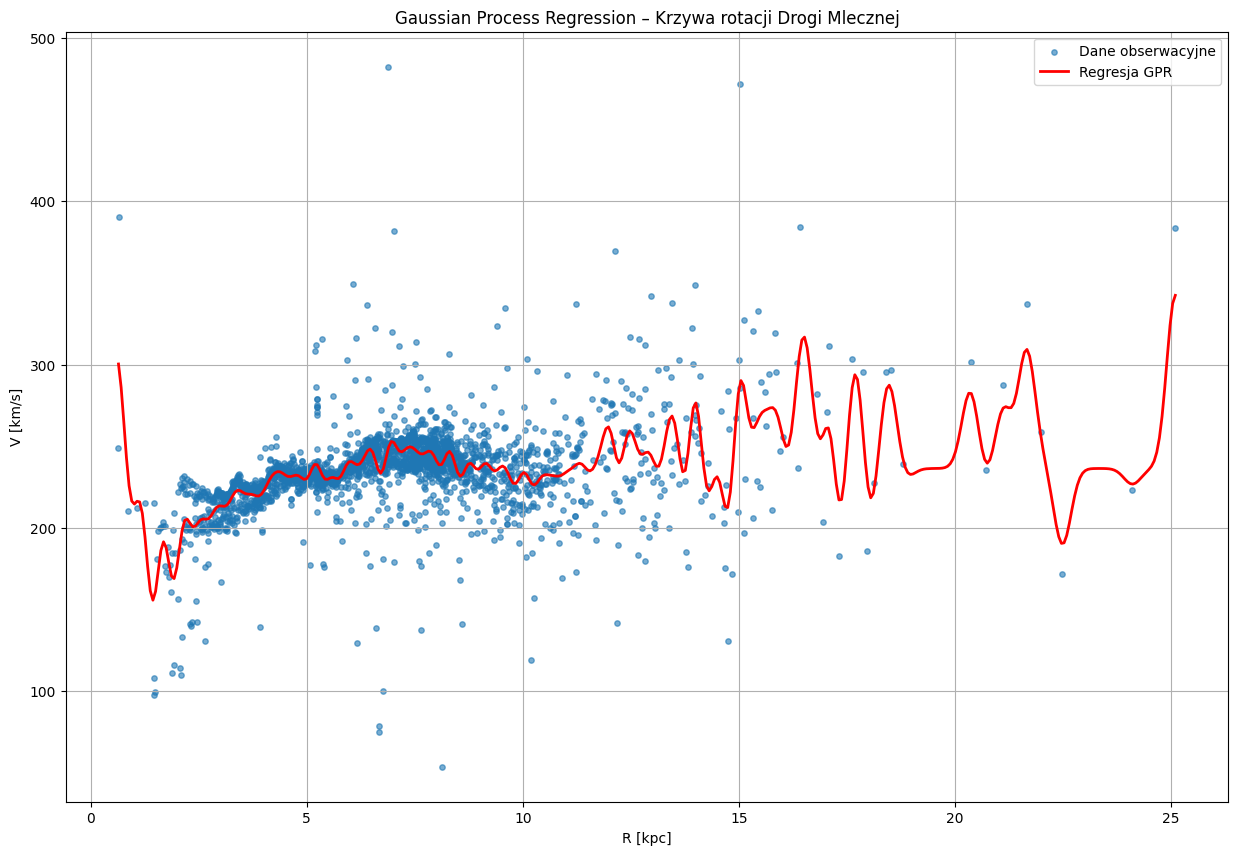

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# dane
file_path = "/content/drive/My Drive/all_montecarlo_output-kopia.dat"

# tylko kolumny R i V
df = pd.read_csv(
    file_path,
    sep=r"\s+",
    comment="#",
    on_bad_lines="skip",   # pomija wiersze z błędami formatowania
    usecols=["R", "V"]     # tylko potrzebne kolumny
)

# usunięcie pojawiających się NaN-y
df = df.dropna(subset=["R", "V"])

# przygotowanie danych
R = df["R"].values.reshape(-1, 1)
V = df["V"].values

# definicja jądra (kernel)
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=15, length_scale_bounds=(0.1, 10.0)) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 10))
# dopasowanie modelu GPR
gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.0, n_restarts_optimizer=5, normalize_y=True)
gpr.fit(R, V)

print("\nDopasowane jądro (kernel):")
print(gpr.kernel_)

# predykcja na gęstej siatce R
R_pred = np.linspace(df["R"].min(), df["R"].max(), 400).reshape(-1, 1)
V_pred, V_std = gpr.predict(R_pred, return_std=True)

# wykres
plt.figure(figsize=(15, 10))
plt.scatter(R, V, color='tab:blue', s=15, label='Dane obserwacyjne', alpha=0.6)
plt.plot(R_pred, V_pred, 'r-', lw=2, label='Regresja GPR')


plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("Gaussian Process Regression – Krzywa rotacji Drogi Mlecznej")
plt.legend()
plt.grid(True)
plt.show()


Porównanie różnych length_scale -> nic to nie daje

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# dane
file_path = "/content/drive/My Drive/all_montecarlo_output-kopia.dat"

df = pd.read_csv(
    file_path,
    sep=r"\s+",
    comment="#",
    on_bad_lines="skip",
    usecols=["R", "V"]
)
df = df.dropna(subset=["R", "V"])

R = df["R"].values.reshape(-1, 1)
V = df["V"].values

# zakres promieni do predykcji w tych samych jednostkach co dane
R_pred = np.linspace(df["R"].min(), df["R"].max(), 400).reshape(-1, 1)

# konfiguracje kernela do porównania
kernels = [
    ("length_scale=0.3",
     ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=0.3, length_scale_bounds=(0.1, 10.0)) +
     WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 10))
    ),
    ("length_scale=1.0",
     ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(0.1, 10.0)) +
     WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 10))
    ),
    ("length_scale=3.0",
     ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=3.0, length_scale_bounds=(0.1, 10.0)) +
     WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 10))
    ),
    ("length_scale=6.0",
     ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=6.0, length_scale_bounds=(0.1, 10.0)) +
     WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 10))
    )
]

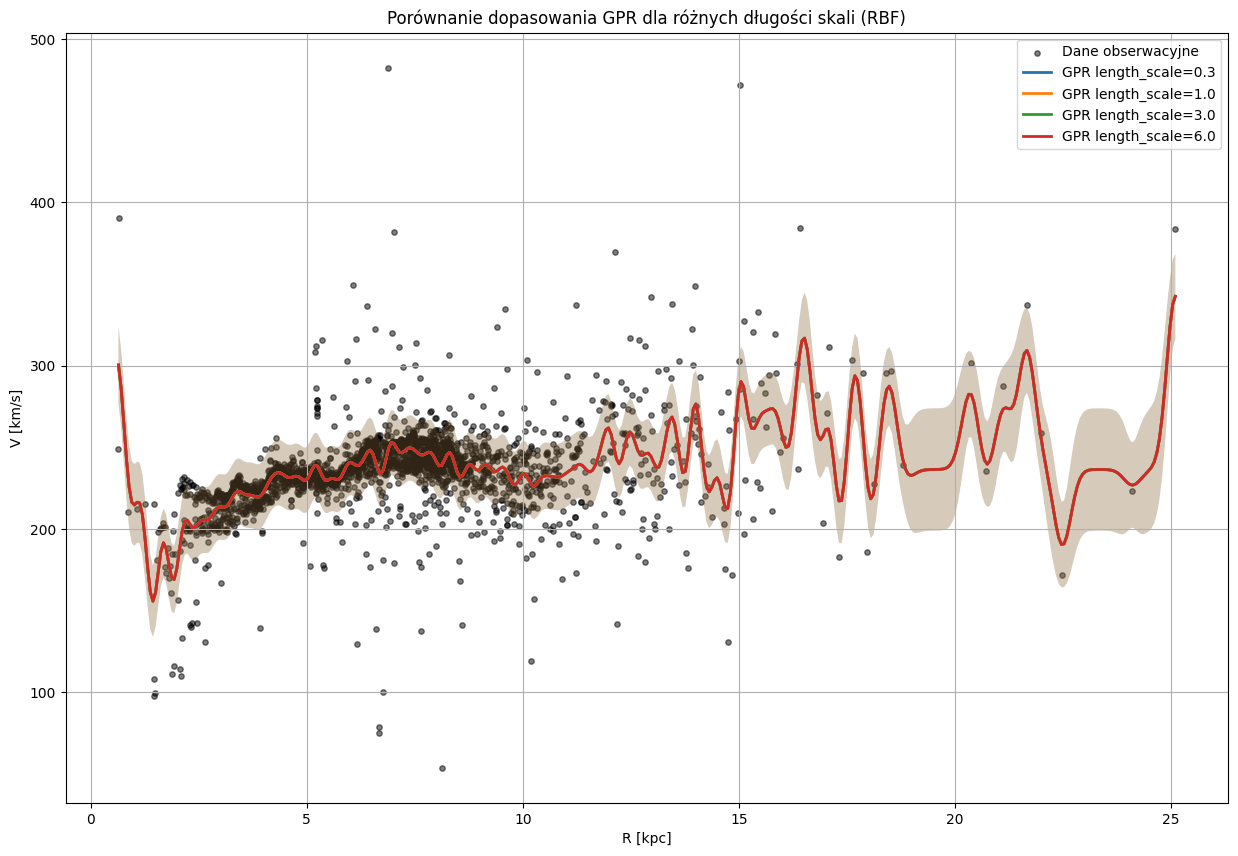

In [38]:

# wykres
plt.figure(figsize=(15, 10))
plt.scatter(R, V, color="black", s=15, label="Dane obserwacyjne", alpha=0.5)

# dopasowanie i rysowanie każdego modelu
for label, kernel in kernels:
    gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, normalize_y=True)
    gpr.fit(R, V)
    V_pred, V_std = gpr.predict(R_pred, return_std=True)
    plt.plot(R_pred, V_pred, lw=2, label=f"GPR {label}")
    plt.fill_between(R_pred.ravel(), V_pred - V_std, V_pred + V_std, alpha=0.1)

plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("Porównanie dopasowania GPR dla różnych długości skali (RBF)")
plt.legend()
plt.grid(True)
plt.show()

# Gaussian Process Regression - R, V, dV

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# dane
file_path = "/content/drive/My Drive/all_montecarlo_output-kopia.dat"

# wczytanie danych z kolumnami R, dR, V, dV, source
df = pd.read_csv(
    file_path,
    sep=r"\s+",
    comment="#",
    on_bad_lines="skip"  # pomijanie złych spacji w kolumnach
)
print(df.head())

# usunięcie pojawiających się NaN-y
df = df.dropna(subset=["R", "V", "dV"])

# przygotowanie danych
R = df["R"].values.reshape(-1, 1)    # wejście w 2D (n, 1)
V = df["V"].values                   # prędkość
dV = df["dV"].values                 # niepewność prędkości

# definicja jądra (kernel)
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=0.5, length_scale_bounds=(0.1, 10.0)) \
          + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 10)) # ConstantKernel to ogólny współczynnik amplitudy, RBF: jądro radialne (gładkość i długość skali), WhiteKernel: poziom szumu (może się dopasować)

# definicja GRP i uczenie modelu
gpr = GaussianProcessRegressor(kernel=kernel, alpha=dV**2, n_restarts_optimizer=3, normalize_y=True)
gpr.fit(R, V)

print("\nDopasowane jądro (kernel):")
print(gpr.kernel_)

# predykcja na gęstej siatce promieni
R_pred = np.linspace(df["R"].min(), df["R"].max(), 400).reshape(-1, 1)
V_pred, V_std = gpr.predict(R_pred, return_std=True)


         R       dR          V       dV   source
0  2.15841  0.04111  205.50930  8.35472  Fich+89
1  2.29867  0.04378  200.56401  8.35891  Fich+89
2  2.43822  0.04644  196.40036  8.36334  Fich+89
3  2.57704  0.04909  197.61713  8.36801  Fich+89
4  2.71506  0.05171  197.11308  8.37290  Fich+89


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



Dopasowane jądro (kernel):
0.384**2 * RBF(length_scale=1.99) + WhiteKernel(noise_level=1e-05)


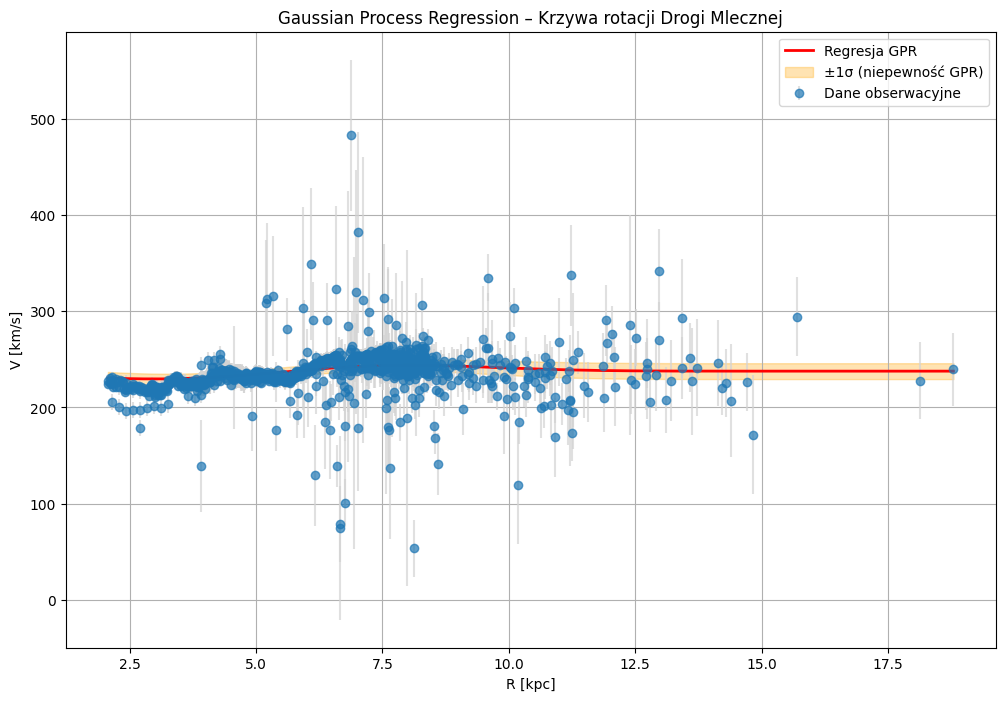

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# wykres
plt.figure(figsize=(15, 10))

# dane obserwacyjne
plt.errorbar(R, V, yerr=dV, fmt='o', color='tab:blue', ecolor='lightgray', label='Dane obserwacyjne', alpha=0.7)

# krzywa GPR (średnia predykcji)
plt.plot(R_pred, V_pred, 'r-', lw=2, label='Regresja GPR')

# pas niepewności ±1σ
plt.fill_between(R_pred.ravel(),
                 V_pred - V_std,
                 V_pred + V_std,
                 color='orange',
                 alpha=0.3,
                 label='±1σ (niepewność GPR)')

plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("Gaussian Process Regression – Krzywa rotacji Drogi Mlecznej")
plt.legend()
plt.grid(True)
plt.show()